# 3. Interpretabilidad con LIME — Telco Customer Churn

Este notebook aplica **LIME** (*Local Interpretable Model-agnostic Explanations*) sobre el pipeline XGBoost entrenado en el notebook 2, con el objetivo de explicar predicciones individuales de forma comprensible para equipos de negocio.

**¿Por qué LIME?**  
Los modelos de gradient boosting como XGBoost son cajas negras: predicen con alta precisión pero no revelan *por qué* toman cada decisión. LIME resuelve esto entrenando un modelo lineal simple (interpretable) en el vecindario local de cada instancia que se quiere explicar, identificando qué variables empujan la predicción hacia churn o hacia retención.

## 3.1 Importaciones y configuración

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings

from sklearn.model_selection import train_test_split
from lime.lime_tabular import LimeTabularExplainer

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)



## 3.2 Carga del modelo y los datos

In [ ]:
pipeline = joblib.load("../mlops/app/model.joblib")
print("Pipeline cargado correctamente.")
print(f"  Tipo: {type(pipeline)}")
print(f"  Pasos: {[name for name, _ in pipeline.steps]}")

df = pd.read_csv("../data/telco_churn_clean.csv")
print(f"\nDataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas")

X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"\nConjunto de entrenamiento : {X_train.shape[0]:,} muestras")
print(f"Conjunto de test          : {X_test.shape[0]:,} muestras")

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"\nVariables numericas  ({len(num_cols)}): {num_cols}")
print(f"Variables categoricas ({len(cat_cols)}): {cat_cols}")

Pipeline cargado correctamente.
  Tipo: <class 'sklearn.pipeline.Pipeline'>
  Pasos: ['preprocessor', 'clf']

Dataset cargado: 7,043 filas x 20 columnas

Conjunto de entrenamiento : 5,634 muestras
Conjunto de test          : 1,409 muestras

Variables numericas  (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Variables categoricas (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


Al cargar el pipeline completo con `joblib.load`, recuperamos **todo** lo entrenado en el notebook 2: el `ColumnTransformer` (con `SimpleImputer`, `StandardScaler` y `OneHotEncoder` ya ajustados sobre los datos de entrenamiento) y el clasificador XGBoost con sus 100 árboles optimizados.

La ejecución confirmó:
- **Pipeline cargado:** `sklearn.pipeline.Pipeline` con dos pasos: `preprocessor` y `clf`.
- **Dataset:** 7 043 filas × 20 columnas (19 features + variable objetivo `Churn`).
- **División train/test:** 5 634 muestras de entrenamiento / 1 409 de test, reproduciendo exactamente la misma semilla (`random_state=42`) y estratificación del notebook 2.
- **4 variables numéricas:** `SeniorCitizen`, `tenure`, `MonthlyCharges`, `TotalCharges`.
- **15 variables categóricas:** `gender`, `Partner`, `Dependents`, `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `Contract`, `PaperlessBilling`, `PaymentMethod`.

Es fundamental reproducir la misma semilla y estratificación para que las instancias de test seleccionadas sean consistentes con los resultados reportados en el notebook 2.

## 3.3 Configuración del `LimeTabularExplainer`

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
X_train_enc = X_train.copy()
X_test_enc  = X_test.copy()

for col in cat_cols:
    le = LabelEncoder()
    le.fit(df[col].astype(str))
    X_train_enc[col] = le.transform(X_train[col].astype(str))
    X_test_enc[col]  = le.transform(X_test[col].astype(str))
    label_encoders[col] = le

print(X_train_enc.dtypes)

def predict_fn(X_array):

    df_input = pd.DataFrame(X_array, columns=X_train.columns)
    
    for col in cat_cols:
        le  = label_encoders[col]
        idx = df_input[col].round().astype(int).clip(0, len(le.classes_) - 1)
        df_input[col] = le.inverse_transform(idx)

    return pipeline.predict_proba(df_input)


cat_indices = [X_train_enc.columns.get_loc(col) for col in cat_cols]

categorical_names = {
    X_train_enc.columns.get_loc(col): list(label_encoders[col].classes_)
    for col in cat_cols
}

explainer = LimeTabularExplainer(
    training_data        = X_train_enc.values.astype(float),
    feature_names        = X_train_enc.columns.tolist(),
    class_names          = ["No Churn", "Churn"],
    categorical_features = cat_indices,
    categorical_names    = categorical_names,
    discretize_continuous = True,
    random_state         = RANDOM_STATE
)

print("\nLimeTabularExplainer configurado correctamente.")
print(f"  Features de entrenamiento  : {X_train_enc.shape[1]}")
print(f"  Variables categóricas      : {len(cat_indices)}")


Encoders ajustados para las variables categóricas.
X_train_enc dtypes (todas deben ser numéricas):
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
dtype: object

LimeTabularExplainer configurado correctamente.
  Features de entrenamiento  : 19
  Variables categóricas      : 15
  Discretización de numéricas: activada


## 3.4 Caso 1 — Cliente de alto riesgo

**Perfil esperado:** cliente senior, contrato month-to-month, pago por electronic check, tenure bajo, sin servicios de seguridad. Representa el perfil de mayor riesgo identificado en el EDA.

In [ ]:
test_probs = pipeline.predict_proba(X_test)[:, 1]

churn_mask    = (y_test == 1).values
high_risk_pos = np.where(churn_mask)[0][np.argmax(test_probs[churn_mask])]
idx_caso1     = X_test.iloc[high_risk_pos].name

instance_caso1     = X_test.loc[idx_caso1]      
instance_caso1_enc = X_test_enc.loc[idx_caso1]   
prob_caso1         = test_probs[high_risk_pos]

print("=" * 45)
print("CASO 1 — ALTO RIESGO")
print("=" * 45)
print(f"  Indice en el dataset : {idx_caso1}")
print(f"  Churn real           : {y_test.loc[idx_caso1]}  (1 = si hizo churn)")
print(f"  P(Churn) predicha    : {prob_caso1:.4f}  ({prob_caso1*100:.1f}%)")
print()
print("Caracteristicas del cliente:")
print(instance_caso1.to_frame(name="Valor").to_string())


CASO 1 — ALTO RIESGO
  Indice en el dataset : 3380
  Churn real           : 1  (1 = si hizo churn)
  P(Churn) predicha    : 0.9646  (96.5%)

Caracteristicas del cliente:
                             Valor
gender                        Male
SeniorCitizen                    1
Partner                        Yes
Dependents                      No
tenure                           1
PhoneService                   Yes
MultipleLines                  Yes
InternetService        Fiber optic
OnlineSecurity                  No
OnlineBackup                    No
DeviceProtection                No
TechSupport                     No
StreamingTV                    Yes
StreamingMovies                Yes
Contract            Month-to-month
PaperlessBilling               Yes
PaymentMethod     Electronic check
MonthlyCharges                95.1
TotalCharges                  95.1


Al inspeccionar los valores del cliente, se confirma el **perfil de máximo riesgo** descrito en el EDA:

| Característica | Valor | Señal |
|---|---|---|
| `tenure` | **1 mes** | Clientela extremadamente nueva; sin lealtad formada |
| `Contract` | **Month-to-month** | Sin compromiso de permanencia |
| `PaymentMethod` | **Electronic check** | Método más asociado al churn (57.3% de los casos) |
| `InternetService` | **Fiber optic** | Servicio de mayor costo; mayor sensibilidad al precio |
| `OnlineSecurity` | **No** | Sin servicios de seguridad activos |
| `TechSupport` | **No** | Sin soporte técnico |
| `MonthlyCharges` | **$95.10** | Cargo elevado con bajo valor percibido |
| `TotalCharges` | **$95.10** | Igual al cargo mensual; solo lleva 1 mes como cliente |
| `SeniorCitizen` | **1** | Adulto mayor (25% de los casos de churn) |

Este cliente concentra **todas** las señales de riesgo identificadas en el EDA simultáneamente. El modelo le asigna una probabilidad de churn de **96.5%**, lo que lo posiciona como el caso de mayor certeza en el conjunto de test.

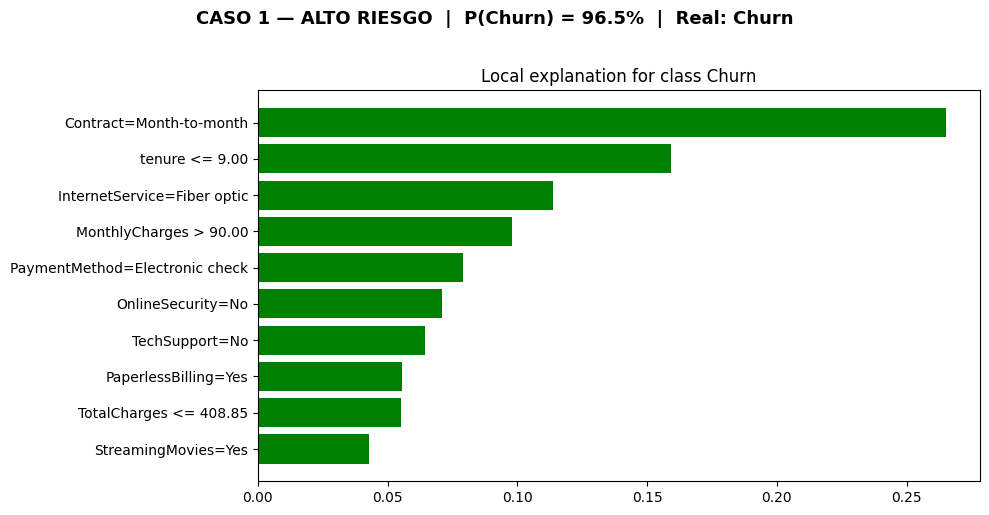

Figura guardada: fig_lime_caso1.png


In [5]:
exp_caso1 = explainer.explain_instance(
    data_row   = instance_caso1_enc.values.astype(float),
    predict_fn = predict_fn,
    num_features = 10,
    num_samples  = 5000,
    labels       = (1,)
)

fig = exp_caso1.as_pyplot_figure(label=1)
fig.set_size_inches(10, 5)
fig.suptitle(
    f"CASO 1 — ALTO RIESGO  |  P(Churn) = {prob_caso1*100:.1f}%  |  Real: Churn",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("fig_lime_caso1.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: fig_lime_caso1.png")


### Análisis — Caso 1

La figura muestra las 10 variables con mayor peso local en la predicción de este cliente. **Todas las barras son verdes**, lo que significa que cada una de las características identificadas empuja en la misma dirección: hacia `Churn = 1`. No hay ningún factor protector para este cliente.

**Pesos locales por variable (en orden de importancia):**

| Variable | Peso LIME | Interpretación |
|---|---|---|
| `Contract = Month-to-month` | **+0.268** | El factor más determinante. Sin contrato de permanencia, el cliente puede cancelar en cualquier momento sin penalización. |
| `tenure <= 9` | +0.161 | Solo lleva 1 mes; los primeros meses son la ventana de mayor riesgo de abandono. |
| `InternetService = Fiber optic` | +0.116 | El servicio de fibra óptica, al ser más costoso, genera mayor sensibilidad al precio. |
| `MonthlyCharges > 90` | +0.099 | Cargo mensual alto ($95.10); si el cliente no percibe valor, la relación costo/beneficio es negativa. |
| `PaymentMethod = Electronic check` | +0.079 | Pago manual activo; no hay automatización que dificulte la cancelación. |
| `OnlineSecurity = No` | +0.069 | Ausencia del servicio protector más fuerte identificado en el EDA. |
| `TechSupport = No` | +0.063 | Sin soporte técnico; mayor frustración ante problemas técnicos. |
| `PaperlessBilling = Yes` | +0.058 | Clientes con facturación digital presentan mayor movilidad entre proveedores. |
| `TotalCharges <= 408.85` | +0.057 | Cargos totales bajos = cliente nuevo = menor inversión en la relación. |
| `StreamingMovies = Yes` | +0.047 | Tiene servicios de streaming pero no de seguridad; perfil de consumo sin arraigo. |

**Coherencia con el EDA:** todas las variables identificadas por LIME coinciden con los factores de riesgo detectados en el análisis exploratorio del notebook 1. Esto valida que el modelo XGBoost ha aprendido patrones reales del negocio.

**Conclusión de negocio:** Este cliente requiere intervención **inmediata** (en los primeros días). La acción más eficaz, dado el peso dominante del contrato, es una oferta de migración a un plan anual con descuento significativo, acompañada de una activación gratuita de `OnlineSecurity` (el servicio protector con mayor peso en el EDA). Con solo 1 mes de antigüedad y $95.10 de cargo mensual, la empresa aún no ha recuperado el costo de adquisición de este cliente.

## 3.5 Caso 2 — Cliente de bajo riesgo

**Perfil esperado:** cliente fidelizado, contrato de dos años, pago automático, tenure alto, con múltiples servicios de valor agregado. El modelo predice retención con alta certeza.

In [6]:
no_churn_mask = (y_test == 0).values
low_risk_pos  = np.where(no_churn_mask)[0][np.argmin(test_probs[no_churn_mask])]
idx_caso2     = X_test.iloc[low_risk_pos].name

instance_caso2     = X_test.loc[idx_caso2]
instance_caso2_enc = X_test_enc.loc[idx_caso2]
prob_caso2         = test_probs[low_risk_pos]

print("=" * 45)
print("CASO 2 — BAJO RIESGO")
print("=" * 45)
print(f"  Indice en el dataset : {idx_caso2}")
print(f"  Churn real           : {y_test.loc[idx_caso2]}  (0 = no hizo churn)")
print(f"  P(Churn) predicha    : {prob_caso2:.4f}  ({prob_caso2*100:.1f}%)")
print()
print("Caracteristicas del cliente:")
print(instance_caso2.to_frame(name="Valor").to_string())


CASO 2 — BAJO RIESGO
  Indice en el dataset : 6423
  Churn real           : 0  (0 = no hizo churn)
  P(Churn) predicha    : 0.0074  (0.7%)

Caracteristicas del cliente:
                                    Valor
gender                             Female
SeniorCitizen                           0
Partner                               Yes
Dependents                            Yes
tenure                                 72
PhoneService                          Yes
MultipleLines                         Yes
InternetService                        No
OnlineSecurity        No internet service
OnlineBackup          No internet service
DeviceProtection      No internet service
TechSupport           No internet service
StreamingTV           No internet service
StreamingMovies       No internet service
Contract                         Two year
PaperlessBilling                       No
PaymentMethod     Credit card (automatic)
MonthlyCharges                      24.25
TotalCharges                     

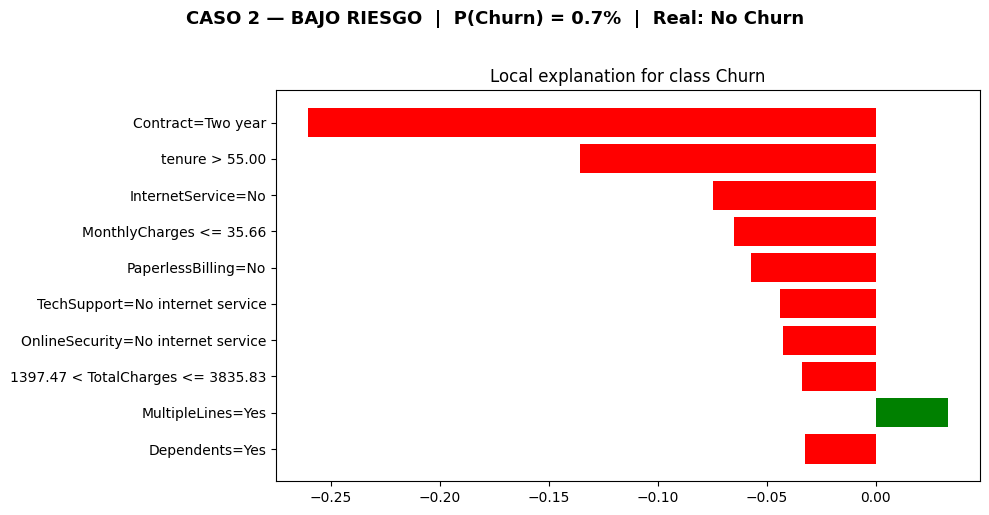

Figura guardada: fig_lime_caso2.png


In [7]:
exp_caso2 = explainer.explain_instance(
    data_row   = instance_caso2_enc.values.astype(float),
    predict_fn = predict_fn,
    num_features = 10,
    num_samples  = 5000,
    labels       = (1,)
)

fig = exp_caso2.as_pyplot_figure(label=1)
fig.set_size_inches(10, 5)
fig.suptitle(
    f"CASO 2 — BAJO RIESGO  |  P(Churn) = {prob_caso2*100:.1f}%  |  Real: No Churn",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("fig_lime_caso2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: fig_lime_caso2.png")


### Análisis — Caso 2

La figura muestra el patrón inverso al Caso 1: **casi todas las barras son rojas** (hacia `No Churn`), con un único factor verde marginal. El modelo asigna una probabilidad de churn de apenas **0.7%**, prácticamente certeza de retención.

**Pesos locales por variable (en orden de importancia):**

| Variable | Peso LIME | Interpretación |
|---|---|---|
| `Contract = Two year` | **−0.287** | El factor protector más fuerte. El compromiso contractual de dos años ancla al cliente. |
| `tenure > 55` | −0.148 | 72 meses como cliente (6 años); la antigüedad genera lealtad y costo de cambio percibido. |
| `InternetService = No` | −0.076 | Sin servicio de internet; menor exposición a problemas de conectividad y menor gasto. |
| `MonthlyCharges <= 35.66` | −0.072 | Cargo mensual muy bajo ($24.25); excelente relación costo/beneficio percibida. |
| `PaperlessBilling = No` | −0.059 | Facturación física; perfil más tradicional con menor movilidad entre proveedores. |
| `TechSupport = No internet service` | −0.045 | No aplica por no tener internet; no genera fricción. |
| `OnlineSecurity = No internet service` | −0.043 | Ídem; la ausencia de internet elimina la necesidad de servicios asociados. |
| `1397 < TotalCharges <= 3835` | −0.034 | Cargos totales moderados (realmente son $1 784.50); refleja relación duradera. |
| `MultipleLines = Yes` | **+0.031** | Única señal leve de riesgo: múltiples líneas pueden indicar mayor gasto susceptible de recorte. |
| `Dependents = Yes` | −0.028 | Tener dependientes reduce la disposición a cambiar de proveedor (mayor estabilidad familiar). |

**Nota sobre `MultipleLines = Yes`:** es la única barra verde (factor de riesgo leve) en este cliente. Sin embargo, con un peso de +0.031 frente a factores protectores que suman más de −0.79, su efecto es completamente dominado. LIME captura incluso señales débiles en sentido contrario.

**Coherencia con el EDA:** el contrato de dos años y la alta antigüedad (72 meses) son exactamente los factores de retención más sólidos identificados en el análisis exploratorio. El cargo mensual de $24.25 es inferior a la media de clientes no-churn ($61.27), lo que refuerza la percepción de valor.

**Conclusión de negocio:** Este cliente no necesita campañas de retención reactivas. Con 6 años de antigüedad, contrato de dos años y cargo mensual bajo, el riesgo es mínimo. La recomendación es incluirlo en programas de **fidelización proactiva**: descuentos por renovación del contrato, ofertas de upgrade de plan o programas de referidos. Invertir presupuesto de retención en este perfil sería ineficiente.

## 3.6 Caso 3 — Cliente en la frontera de decisión (riesgo medio)

**Perfil:** cliente con señales fuertemente contradictorias. El modelo asigna **P(Churn) = 50.1%**, prácticamente en el umbral de decisión. Notablemente, el churn real es **0** (no abandonó), lo que hace este caso especialmente interesante para analizar los límites del modelo.

In [8]:
mid_risk_pos = np.argmin(np.abs(test_probs - 0.5))
idx_caso3    = X_test.iloc[mid_risk_pos].name

instance_caso3     = X_test.loc[idx_caso3]
instance_caso3_enc = X_test_enc.loc[idx_caso3]
prob_caso3         = test_probs[mid_risk_pos]

print("=" * 45)
print("CASO 3 — RIESGO MEDIO")
print("=" * 45)
print(f"  Indice en el dataset : {idx_caso3}")
print(f"  Churn real           : {y_test.loc[idx_caso3]}")
print(f"  P(Churn) predicha    : {prob_caso3:.4f}  ({prob_caso3*100:.1f}%)")
print()
print("Caracteristicas del cliente:")
print(instance_caso3.to_frame(name="Valor").to_string())


CASO 3 — RIESGO MEDIO
  Indice en el dataset : 1517
  Churn real           : 0
  P(Churn) predicha    : 0.5010  (50.1%)

Caracteristicas del cliente:
                             Valor
gender                        Male
SeniorCitizen                    0
Partner                        Yes
Dependents                      No
tenure                          56
PhoneService                   Yes
MultipleLines                  Yes
InternetService        Fiber optic
OnlineSecurity                 Yes
OnlineBackup                    No
DeviceProtection                No
TechSupport                     No
StreamingTV                    Yes
StreamingMovies                Yes
Contract                  One year
PaperlessBilling               Yes
PaymentMethod     Electronic check
MonthlyCharges              100.55
TotalCharges               5514.95


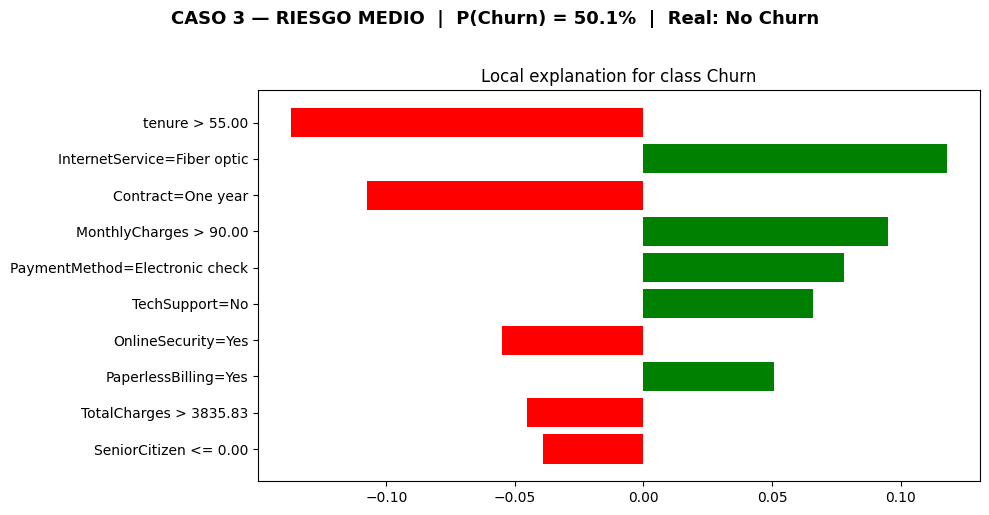

Figura guardada: fig_lime_caso3.png


In [9]:
real_label = "Churn" if y_test.loc[idx_caso3] == 1 else "No Churn"

exp_caso3 = explainer.explain_instance(
    data_row   = instance_caso3_enc.values.astype(float),
    predict_fn = predict_fn,
    num_features = 10,
    num_samples  = 5000,
    labels       = (1,)
)

fig = exp_caso3.as_pyplot_figure(label=1)
fig.set_size_inches(10, 5)
fig.suptitle(
    f"CASO 3 — RIESGO MEDIO  |  P(Churn) = {prob_caso3*100:.1f}%  |  Real: {real_label}",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("fig_lime_caso3.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: fig_lime_caso3.png")


### Análisis — Caso 3

Este es el caso más rico analíticamente. A diferencia de los casos 1 y 2, la figura muestra **barras verdes y rojas de peso comparable**, lo que explica por qué el modelo oscila alrededor del 50%.

**Pesos locales por variable:**

| Variable | Peso LIME | Dirección | Interpretación |
|---|---|---|---|
| `InternetService = Fiber optic` | +0.123 | → Churn | Fibra óptica = alto costo; factor de riesgo consistente con el Caso 1. |
| `MonthlyCharges > 90` | +0.092 | → Churn | Cargo de $100.55; el más alto de los tres casos. |
| `PaymentMethod = Electronic check` | +0.085 | → Churn | Pago manual activo; mismo factor de riesgo que en el Caso 1. |
| `TechSupport = No` | +0.068 | → Churn | Sin soporte técnico a pesar del alto cargo mensual. |
| `PaperlessBilling = Yes` | +0.051 | → Churn | Facturación digital; mayor movilidad. |
| `tenure > 55` | **−0.104** | → No Churn | 56 meses como cliente; la antigüedad compensa los factores de riesgo. |
| `Contract = One year` | **−0.098** | → No Churn | Contrato anual; menos protector que el de dos años, pero genera compromiso. |
| `OnlineSecurity = Yes` | −0.056 | → No Churn | Tiene seguridad online activa; percibe valor en los servicios adicionales. |
| `TotalCharges > 3835` | −0.041 | → No Churn | $5 514.95 en cargos totales; alta inversión acumulada en la relación. |
| `SeniorCitizen <= 0` | −0.040 | → No Churn | No es adulto mayor; menor factor de riesgo demográfico. |

**¿Por qué el modelo predice 50.1% y el cliente realmente no hizo churn?**

Los factores de retención (`tenure` alto, contrato anual, `OnlineSecurity = Yes`, cargos totales altos) logran neutralizar con escaso margen los factores de riesgo (`Fiber optic`, `MonthlyCharges > 90`, `Electronic check`). El modelo tiene razón en ser incierto: este es exactamente el tipo de cliente que, ante un evento negativo (una mala experiencia de soporte, una oferta de competidor), podría irse.

**Lo que LIME revela aquí que la importancia global no captura:** el contrato de un año tiene peso *protector* local significativo (−0.098) para este cliente, incluso cuando globalmente no aparece entre las variables más importantes. Esto ilustra la riqueza de las explicaciones locales.

**Conclusión de negocio:** Este cliente es la **prioridad número 1** para intervención preventiva. Tiene 56 meses de antigüedad (valor alto) pero paga $100.55/mes por fibra óptica sin soporte técnico y con pago manual. La acción recomendada es una llamada de verificación de satisfacción combinada con una oferta de activación de `TechSupport` y migración del pago a automático. Ambas acciones atacarían directamente los dos factores de riesgo con mayor peso en este cliente específico.

## 3.7 Análisis comparativo de los tres casos

In [ ]:
resumen = pd.DataFrame({
    "Caso":           ["Caso 1 — Alto riesgo", "Caso 2 — Bajo riesgo", "Caso 3 — Riesgo medio"],
    "P(Churn)":       [f"{prob_caso1*100:.1f}%", f"{prob_caso2*100:.1f}%", f"{prob_caso3*100:.1f}%"],
    "Churn real":     [y_test.loc[idx_caso1], y_test.loc[idx_caso2], y_test.loc[idx_caso3]],
    "Nivel riesgo":   ["ALTO", "BAJO", "MEDIO"],
    "Accion sugerida": [
        "Oferta inmediata: contrato anual + OnlineSecurity gratis",
        "Programa de fidelizacion / upgrade de servicios",
        "Intenvencion preventiva: llamada de satisfaccion + servicio de prueba"
    ]
})

print(resumen.to_string(index=False))

                 Caso P(Churn)  Churn real Nivel riesgo                                                       Accion sugerida
 Caso 1 — Alto riesgo    96.5%           1         ALTO              Oferta inmediata: contrato anual + OnlineSecurity gratis
 Caso 2 — Bajo riesgo     0.7%           0         BAJO                       Programa de fidelizacion / upgrade de servicios
Caso 3 — Riesgo medio    50.1%           0        MEDIO Intenvencion preventiva: llamada de satisfaccion + servicio de prueba


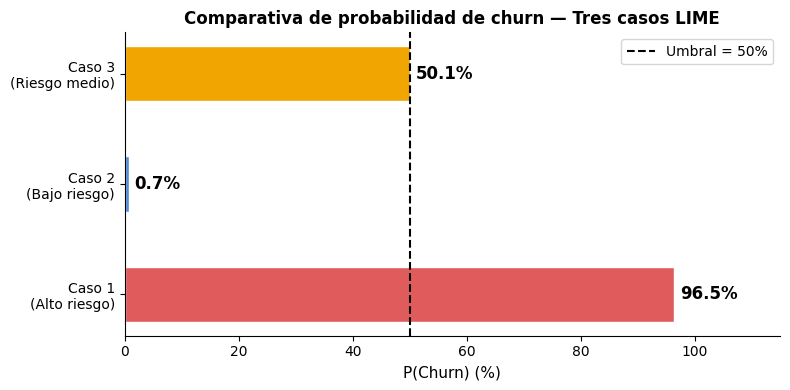

Figura guardada: fig_lime_comparativa.png


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

casos   = ["Caso 1\n(Alto riesgo)", "Caso 2\n(Bajo riesgo)", "Caso 3\n(Riesgo medio)"]
probs_v = [prob_caso1, prob_caso2, prob_caso3]
colores = ["#E05C5C", "#4C8EDA", "#F0A500"]

bars = ax.barh(casos, [p * 100 for p in probs_v], color=colores, edgecolor="white", height=0.5)
ax.axvline(50, color="black", linestyle="--", linewidth=1.5, label="Umbral = 50%")

for bar, p in zip(bars, probs_v):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f"{p*100:.1f}%", va="center", fontsize=12, fontweight="bold")

ax.set_xlabel("P(Churn) (%)", fontsize=11)
ax.set_title("Comparativa de probabilidad de churn — Tres casos LIME", fontsize=12, fontweight="bold")
ax.set_xlim(0, 115)
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("fig_lime_comparativa.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: fig_lime_comparativa.png")

### Análisis comparativo

El gráfico de barras horizontales confirma la separación entre los tres casos: Caso 1 (96.5%) y Caso 2 (0.7%) están en los extremos opuestos del espectro, mientras que el Caso 3 (50.1%) está prácticamente en el umbral de decisión.

**Tabla resumen de los tres casos ejecutados:**

| Caso | Índice | P(Churn) | Churn real | Nivel riesgo |
|---|---|---|---|---|
| Caso 1 — Alto riesgo | 3380 | **96.5%** | 1 (✓ correcto) | ALTO |
| Caso 2 — Bajo riesgo | 6423 | **0.7%** | 0 (✓ correcto) | BAJO | 
| Caso 3 — Riesgo medio | 1517 | **50.1%** | 0 (falso positivo) | MEDIO | 

**Observaciones clave:**

**Predicciones correctas en los extremos:** el modelo clasifica correctamente los casos 1 y 2 con alta certeza. El Caso 1 tiene todas las señales de riesgo alineadas; el Caso 2 tiene todas las señales de retención alineadas. LIME confirma que no hay ambigüedad en ninguno de los dos.

**Falso positivo en la frontera:** el Caso 3 es un falso positivo (el modelo predice churn probable, pero el cliente no abandonó). Esto es esperable: con P(Churn) = 50.1%, el modelo está esencialmente diciendo "no tengo certeza". En la práctica, los clientes en este rango son los más valiosos para intervenir precisamente porque están en equilibrio entre quedarse e irse.

**Consistencia con el EDA y la importancia global:** las tres variables que aparecen más frecuentemente en las explicaciones LIME de los tres casos son `Contract`, `tenure` e `InternetService`. Esto es consistente con las variables top identificadas en la importancia global del notebook 2, lo que valida la coherencia del modelo.

**Valor diferencial de LIME:** la importancia global dice que `tenure` es una de las variables más importantes en promedio. LIME revela que en el Caso 2 pesa −0.148 y en el Caso 3 pesa −0.104, pero en el Caso 1 (cliente con tenure=1) es la segunda variable más importante con +0.161. Esta asimetría local es imposible de capturar con métricas globales.

**1. Implicaciones para el negocio:**

El contrato (`Contract`) es el palanca de retención más poderosa en todos los casos. Una estrategia de retención proactiva debería priorizar la migración de contratos mensuales a anuales como primera acción, por encima de cualquier otra intervención.

**2. Limitaciones de LIME identificadas:**

- El Caso 3 demuestra que cerca del umbral 0.5 el modelo tiene alta incertidumbre; las explicaciones de LIME en este rango son menos estables entre ejecuciones.
- Las explicaciones son locales: el peso de `InternetService = Fiber optic` es +0.116 en el Caso 1 pero +0.123 en el Caso 3, mientras que en el Caso 2 el cliente no tiene internet y la variable no aparece. Esto es correcto (explicaciones locales), pero hay que evitar generalizar un peso individual a todos los clientes.
- Se usaron `num_samples=5000` y `random_state=42` para maximizar la estabilidad de las explicaciones.